**Steps To Understand The Code**
1. Importing the important libreries
2. Loading both the datasets
3. Printing the first 5 rows of both the datasets
4. Cleaning the sms dataset
5. Cleaning the email dataset
6. Text preprocessing (only lowercase + cleaning)
7. Convert text to numbers (tf-idf)
8. Train test split for both sms and email
9. Logistic regression training + evaluation sms
10. Random forest — training & evaluation (sms)
11. Xgboost — improved training & evaluation (sms)
12. Printing everything of sms machine learning
13. Logistic regression (email)
14. Random forest (email)
15. Xgboost (email)
16. Printing everything of email machine learning
17. Creating hybrid model for sms
18. Printing everything for hybrid model sms
19. Creating hybrid model for email
20. Printing everything for hybrid model email
21. Shap for sms
22. Shap for email
23. Lime for sms
24. Lime for email

In [1]:
#Step - 01 Importing the important libreries
!pip install lime
import pandas as pd
import numpy as np
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adity\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\adity\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [11]:
!pip install openpyxl
sms_df = pd.read_excel('D:/Semester - 06/Mini Project - II/Email spam.xlsx')
email_df = pd.read_excel('D:/Semester - 06/Mini Project - II/sms spam.xlsx')


   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [open

In [12]:
# Step - 03 Printing the first 5 rows of both the datasets
sms_df.head()
email_df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
# Step - 04 CLEAN SMS DATASET
# Keep only required columns
sms_df = sms_df[['v1', 'v2']]
# Rename columns
sms_df.columns = ['label', 'text']
# Convert labels to numbers
sms_df['label'] = sms_df['label'].map({'ham': 0, 'spam': 1})
#To verify SMS cleaned successfully
sms_df['label'].value_counts()

KeyError: "None of [Index(['v1', 'v2'], dtype='object')] are in the [columns]"

In [ ]:
# Step - 05 Clean Email dataset
# Keep only required columns
email_df = email_df[['Email Text', 'Email Type']]
# Rename columns to match SMS dataset
email_df.columns = ['text', 'label']
# Convert labels to numbers
email_df['label'] = email_df['label'].map({'Safe Email': 0,'Phishing Email': 1})
#To verify Email cleaned successfully
email_df['label'].value_counts()

,count
label,
0.0,3472
1.0,2304


In [ ]:
# Step - 06 TEXT PREPROCESSING (only lowercase + cleaning)
#Tools initialized
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
# Creating the text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]
    return " ".join(words)
# Text cleaning function working or not
clean_text("Congratulations! You have WON 1000 rupees!!!")
# Applying the text cleaning function
sms_df['clean_text'] = sms_df['text'].apply(clean_text)
email_df['clean_text'] = email_df['text'].apply(clean_text)
# Verifying Text preprocessing applied or not
sms_df[['text', 'clean_text']].head()
email_df[['text', 'clean_text']].head()

,text,clean_text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",disc uniformitarianism sex lang dick hudson ob...
1,the other side of * galicismos * * galicismo *...,side galicismos galicismo spanish term name im...
2,re : equistar deal tickets are you still avail...,equistar deal ticket still available assist ro...
3,\nHello I am your hot lil horny toy.\n I am...,hello hot lil horny toy one dream open minded ...
4,software at incredibly low prices ( 86 % lower...,software incredibly low price lower drapery se...


In [ ]:
# Step - 07 Convert text to numbers (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer
#TF-IDF object created
tfidf = TfidfVectorizer(max_features=5000)
# APPLY TF-IDF TO SMS DATA
X_sms = tfidf.fit_transform(sms_df['clean_text'])
y_sms = sms_df['label']
X_sms.shape
# APPLY TF-IDF TO Email DATA
X_email = tfidf.fit_transform(email_df['clean_text'])
y_email = email_df['label']
X_email.shape

(6499, 5000)

In [ ]:
# Step - 08 Train-Test Split for both sms and email
from sklearn.model_selection import train_test_split
# SMS train-test split
X_sms_train, X_sms_test, y_sms_train, y_sms_test = train_test_split(X_sms, y_sms, test_size=0.2, random_state=42)
X_sms_train.shape, X_sms_test.shape
#Email train-test split
email_df = email_df.dropna(subset=['label'])
X_email = tfidf.fit_transform(email_df['clean_text'])
y_email = email_df['label']
X_email_train, X_email_test, y_email_train, y_email_test = train_test_split(X_email, y_email, test_size=0.2, random_state=42)
X_sms_train.shape, X_sms_test.shape

((4399, 5000), (1100, 5000))

In [ ]:
# Step - 09 Logistic regression training + evaluation sms
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
lr_sms = LogisticRegression(max_iter=1000)
lr_sms.fit(X_sms_train, y_sms_train)
y_sms_pred = lr_sms.predict(X_sms_test)
print("SMS Logistic Regression Accuracy:")
print(accuracy_score(y_sms_test, y_sms_pred))
print("\nClassification Report:")
print(classification_report(y_sms_test, y_sms_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_sms_test, y_sms_pred))

SMS Logistic Regression Accuracy:
0.9527272727272728

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       939
           1       0.99      0.68      0.81       161

    accuracy                           0.95      1100
   macro avg       0.97      0.84      0.89      1100
weighted avg       0.95      0.95      0.95      1100


Confusion Matrix:
[[938   1]
 [ 51 110]]


In [ ]:
# Step - 10 Random forest — training & evaluation (sms)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
rf_sms = RandomForestClassifier(n_estimators=400,random_state=42,class_weight='balanced')
rf_sms.fit(X_sms_train, y_sms_train)
y_sms_pred_rf = rf_sms.predict(X_sms_test)
print("SMS Random Forest Accuracy:")
print(accuracy_score(y_sms_test, y_sms_pred_rf))
print("\nClassification Report:")
print(classification_report(y_sms_test, y_sms_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_sms_test, y_sms_pred_rf))

SMS Random Forest Accuracy:
0.98

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       939
           1       1.00      0.86      0.93       161

    accuracy                           0.98      1100
   macro avg       0.99      0.93      0.96      1100
weighted avg       0.98      0.98      0.98      1100


Confusion Matrix:
[[939   0]
 [ 22 139]]


In [ ]:
# Step - 11 Xgboost — improved training & evaluation (sms)
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Calculate class imbalance ratio for spam vs ham
spam_count = sum(y_sms_train == 1)
ham_count = sum(y_sms_train == 0)
scale_pos_weight = ham_count / spam_count  # imbalance ratio
# Create XGBoost model with tuned hyperparameters
xgb_sms_tuned = XGBClassifier(n_estimators=600,learning_rate=0.05,max_depth=10,subsample=0.8,colsample_bytree=0.8,scale_pos_weight=scale_pos_weight,random_state=42,use_label_encoder=False,eval_metric='logloss')
# Train model
xgb_sms_tuned.fit(X_sms_train, y_sms_train)
# Predict on test set
y_sms_pred_xgb_tuned = xgb_sms_tuned.predict(X_sms_test)
# Evaluate performance
print("SMS XGBoost Tuned Accuracy:")
print(accuracy_score(y_sms_test, y_sms_pred_xgb_tuned))
print("\nClassification Report:")
print(classification_report(y_sms_test, y_sms_pred_xgb_tuned))
print("\nConfusion Matrix:")
print(confusion_matrix(y_sms_test, y_sms_pred_xgb_tuned))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:17:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SMS XGBoost Tuned Accuracy:
0.9754545454545455

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       939
           1       0.92      0.91      0.92       161

    accuracy                           0.98      1100
   macro avg       0.95      0.95      0.95      1100
weighted avg       0.98      0.98      0.98      1100


Confusion Matrix:
[[927  12]
 [ 15 146]]


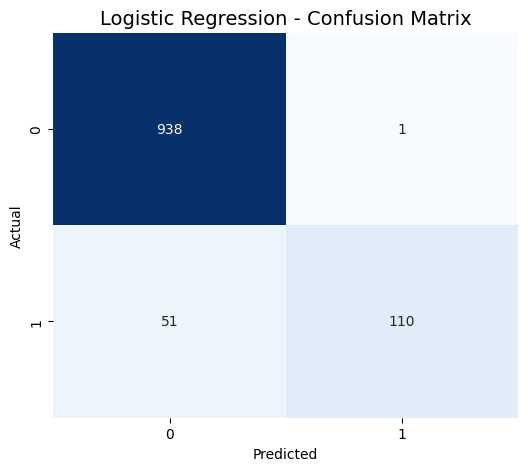

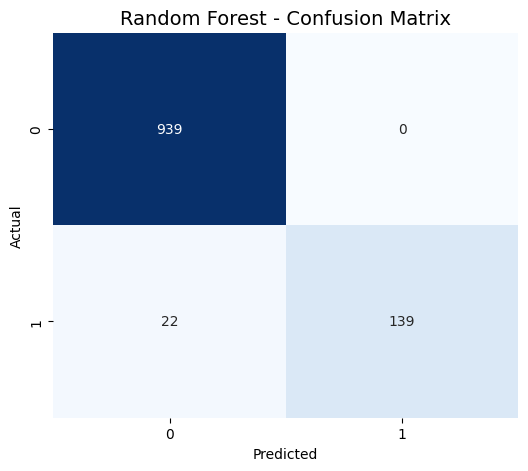

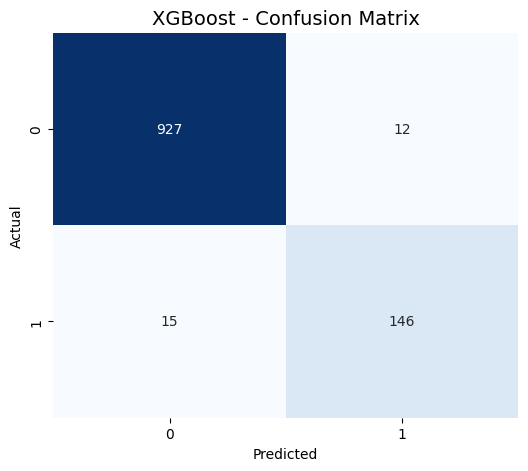

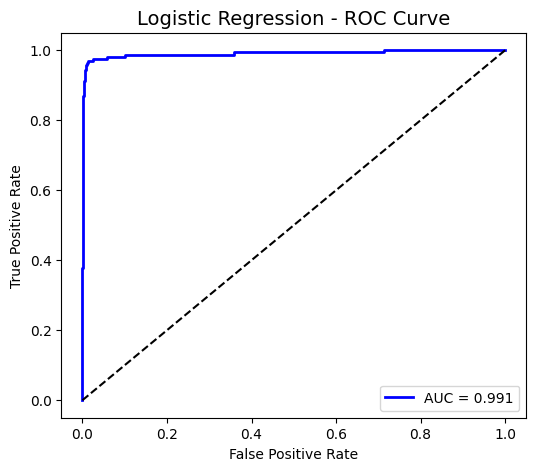

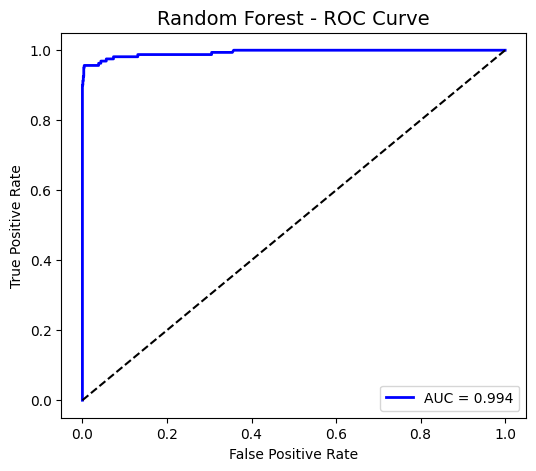

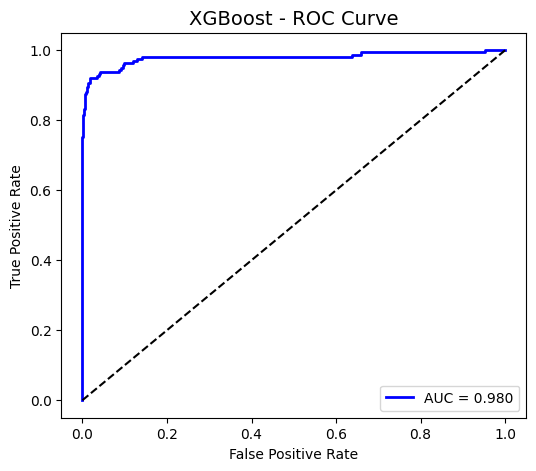

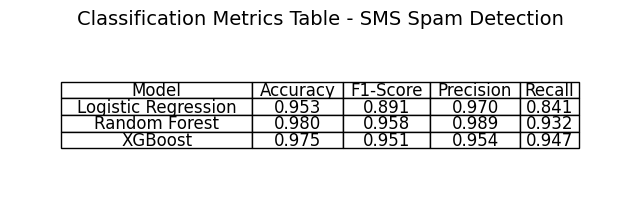

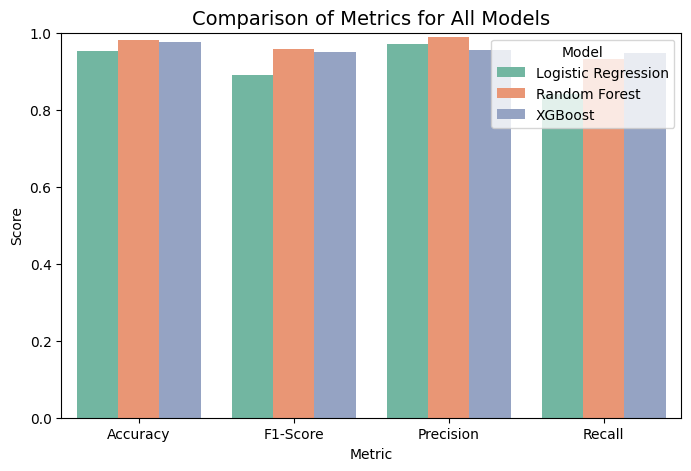

In [ ]:
# Step - 12 Printing everything of SMS machine learning
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report, accuracy_score
# Models dictionary
models = {"Logistic Regression": lr_sms,"Random Forest": rf_sms,"XGBoost": xgb_sms_tuned}
for name, model in models.items():
    y_pred = model.predict(X_sms_test)
    cm = confusion_matrix(y_sms_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} - Confusion Matrix", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
for name, model in models.items():
    y_proba = model.predict_proba(X_sms_test)[:,1]
    fpr, tpr, _ = roc_curve(y_sms_test, y_proba)
    auc = roc_auc_score(y_sms_test, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc:.3f}", linewidth=2)
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f"{name} - ROC Curve", fontsize=14)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()
results = []
for name, model in models.items():
    y_pred = model.predict(X_sms_test)
    accuracy = accuracy_score(y_sms_test, y_pred)
    report = classification_report(y_sms_test, y_pred, output_dict=True)
    f1 = report['macro avg']['f1-score']
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    results.append({
        "Model": name,
        "Accuracy": f"{accuracy:.3f}",
        "F1-Score": f"{f1:.3f}",
        "Precision": f"{precision:.3f}",
        "Recall": f"{recall:.3f}"
    })
# Convert to DataFrame
results_df = pd.DataFrame(results)
# Plot table
fig, ax = plt.subplots(figsize=(8,2))
ax.axis('off')
tbl = ax.table(cellText=results_df.values,colLabels=results_df.columns,cellLoc='center',loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.auto_set_column_width(range(len(results_df.columns)))
plt.title("Classification Metrics Table - SMS Spam Detection", fontsize=14, pad=10)
plt.show()
metrics = ["Accuracy","F1-Score","Precision","Recall"]
results_df_melt = results_df.melt(id_vars="Model", value_vars=metrics, var_name="Metric", value_name="Score")
# Convert score to float for plotting
results_df_melt["Score"] = results_df_melt["Score"].astype(float)
plt.figure(figsize=(8,5))
sns.barplot(data=results_df_melt, x="Metric", y="Score", hue="Model", palette="Set2")
plt.ylim(0,1)
plt.title("Comparison of Metrics for All Models", fontsize=14)
plt.ylabel("Score")
plt.show()

In [ ]:
# Step-13 Logistic Regression (Email)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
lr_email = LogisticRegression(max_iter=1000)
lr_email.fit(X_email_train, y_email_train)
y_email_pred_lr = lr_email.predict(X_email_test)
print("Email Logistic Regression Accuracy:")
print(accuracy_score(y_email_test, y_email_pred_lr))
print("\nClassification Report:")
print(classification_report(y_email_test, y_email_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_email_test, y_email_pred_lr))

Email Logistic Regression Accuracy:
0.9506920415224913

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96       691
         1.0       0.95      0.92      0.94       465

    accuracy                           0.95      1156
   macro avg       0.95      0.95      0.95      1156
weighted avg       0.95      0.95      0.95      1156


Confusion Matrix:
[[670  21]
 [ 36 429]]


In [ ]:
# Step-14 Random Forest (Email)
from sklearn.ensemble import RandomForestClassifier
rf_email = RandomForestClassifier(n_estimators=400,random_state=42,class_weight='balanced')
rf_email.fit(X_email_train, y_email_train)
y_email_pred_rf = rf_email.predict(X_email_test)
print("Email Random Forest Accuracy:")
print(accuracy_score(y_email_test, y_email_pred_rf))
print("\nClassification Report:")
print(classification_report(y_email_test, y_email_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_email_test, y_email_pred_rf))

Email Random Forest Accuracy:
0.9532871972318339

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.95      0.96       691
         1.0       0.92      0.97      0.94       465

    accuracy                           0.95      1156
   macro avg       0.95      0.96      0.95      1156
weighted avg       0.95      0.95      0.95      1156


Confusion Matrix:
[[653  38]
 [ 16 449]]


In [ ]:
# Step-15 XGBoost (Email)
from xgboost import XGBClassifier
# Handle class imbalance
phish_count = sum(y_email_train == 1)
safe_count = sum(y_email_train == 0)
scale_pos_weight_email = safe_count / phish_count
xgb_email_tuned = XGBClassifier(n_estimators=600,learning_rate=0.05,max_depth=10,subsample=0.8,colsample_bytree=0.8,scale_pos_weight=scale_pos_weight_email,random_state=42,use_label_encoder=False,eval_metric='logloss')
xgb_email_tuned.fit(X_email_train, y_email_train)
y_email_pred_xgb = xgb_email_tuned.predict(X_email_test)
print("Email XGBoost Tuned Accuracy:")
print(accuracy_score(y_email_test, y_email_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_email_test, y_email_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_email_test, y_email_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:17:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Email XGBoost Tuned Accuracy:
0.9541522491349481

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.94      0.96       691
         1.0       0.91      0.98      0.94       465

    accuracy                           0.95      1156
   macro avg       0.95      0.96      0.95      1156
weighted avg       0.96      0.95      0.95      1156


Confusion Matrix:
[[648  43]
 [ 10 455]]


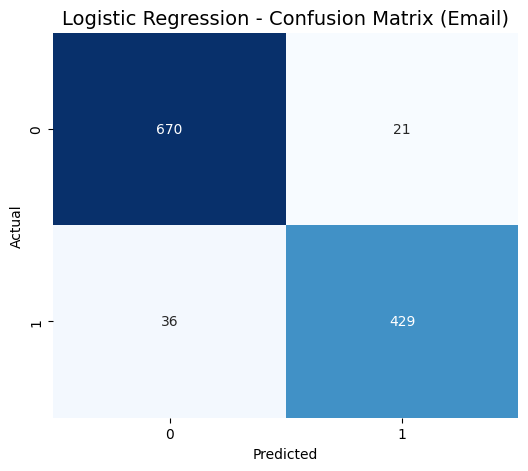

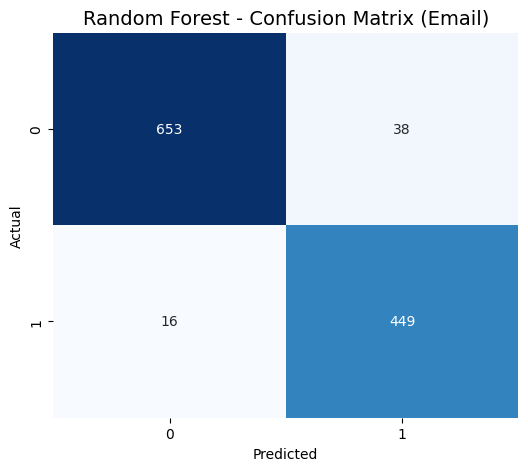

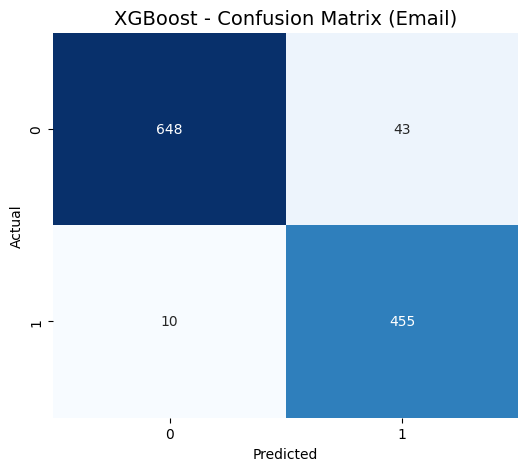

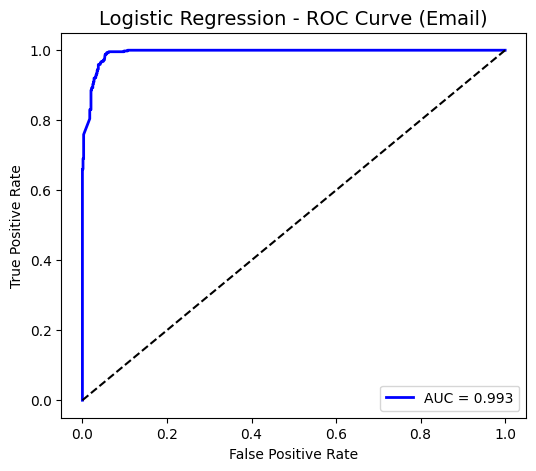

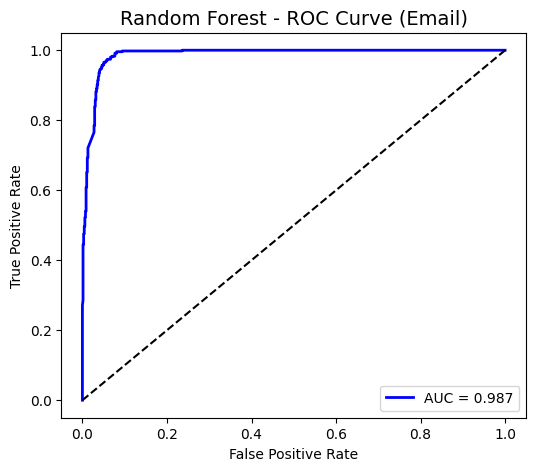

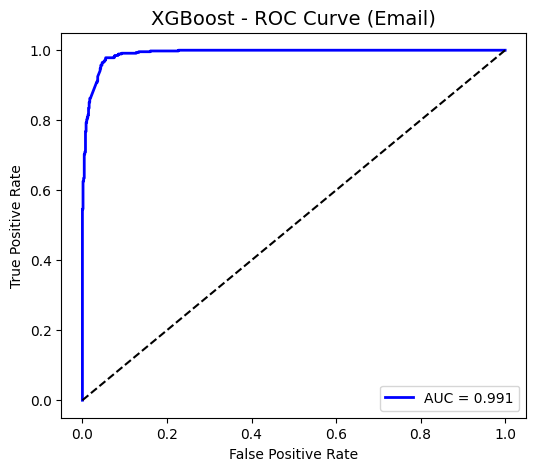

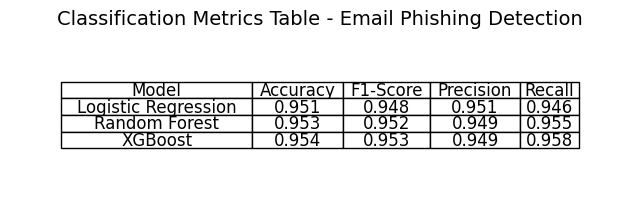

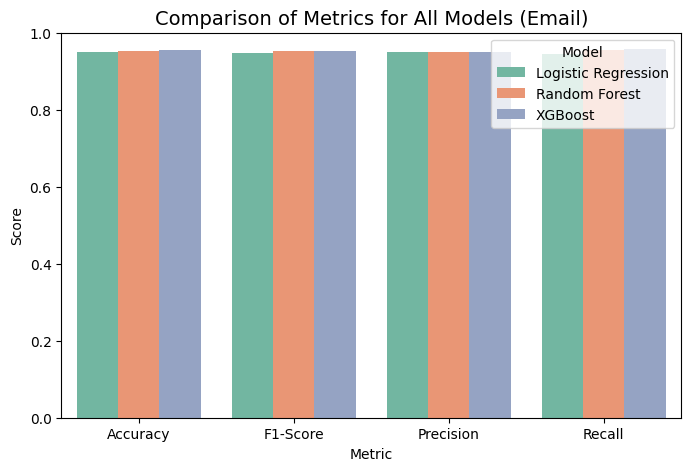

In [ ]:
# Step-16 Printing everything of Email machine learning
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report, accuracy_score
models_email = {"Logistic Regression": lr_email,"Random Forest": rf_email,"XGBoost": xgb_email_tuned}
for name, model in models_email.items():
    y_pred = model.predict(X_email_test)
    cm = confusion_matrix(y_email_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} - Confusion Matrix (Email)", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
for name, model in models_email.items():
    y_proba = model.predict_proba(X_email_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_email_test, y_proba)
    auc = roc_auc_score(y_email_test, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc:.3f}", linewidth=2)
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f"{name} - ROC Curve (Email)", fontsize=14)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()
results_email = []
for name, model in models_email.items():
    y_pred = model.predict(X_email_test)
    accuracy = accuracy_score(y_email_test, y_pred)
    report = classification_report(y_email_test, y_pred, output_dict=True)
    results_email.append({"Model": name,"Accuracy": f"{accuracy:.3f}","F1-Score": f"{report['macro avg']['f1-score']:.3f}","Precision": f"{report['macro avg']['precision']:.3f}","Recall": f"{report['macro avg']['recall']:.3f}"})
results_email_df = pd.DataFrame(results_email)
fig, ax = plt.subplots(figsize=(8,2))
ax.axis('off')
tbl = ax.table(cellText=results_email_df.values,colLabels=results_email_df.columns,cellLoc='center',loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.auto_set_column_width(range(len(results_email_df.columns)))
plt.title("Classification Metrics Table - Email Phishing Detection", fontsize=14, pad=10)
plt.show()
metrics = ["Accuracy", "F1-Score", "Precision", "Recall"]
results_email_melt = results_email_df.melt(id_vars="Model",value_vars=metrics,var_name="Metric",value_name="Score")
results_email_melt["Score"] = results_email_melt["Score"].astype(float)
plt.figure(figsize=(8,5))
sns.barplot(data=results_email_melt,x="Metric",y="Score",hue="Model",palette="Set2")
plt.ylim(0,1)
plt.title("Comparison of Metrics for All Models (Email)", fontsize=14)
plt.ylabel("Score")
plt.show()

In [ ]:
# Step - 17 creating hybrid model for SMS
from sklearn.ensemble import VotingClassifier
hybrid_sms = VotingClassifier(estimators=[('lr', lr_sms),('rf', rf_sms),('xgb', xgb_sms_tuned)],voting='soft')
hybrid_sms.fit(X_sms_train, y_sms_train)
y_sms_pred_hybrid = hybrid_sms.predict(X_sms_test)
print("SMS Hybrid Model Accuracy:")
print(accuracy_score(y_sms_test, y_sms_pred_hybrid))
print("\nClassification Report:")
print(classification_report(y_sms_test, y_sms_pred_hybrid))
print("\nConfusion Matrix:")
print(confusion_matrix(y_sms_test, y_sms_pred_hybrid))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:20:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# STEP-18: PRINTING EVERYTHING FOR HYBRID MODEL – SMS
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report, accuracy_score
models_sms_hybrid = {"Hybrid Model": hybrid_sms}
for name, model in models_sms_hybrid.items():
    y_pred = model.predict(X_sms_test)
    cm = confusion_matrix(y_sms_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} - Confusion Matrix (SMS)", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
for name, model in models_sms_hybrid.items():
    y_proba = model.predict_proba(X_sms_test)[:,1]
    fpr, tpr, _ = roc_curve(y_sms_test, y_proba)
    auc = roc_auc_score(y_sms_test, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc:.3f}", linewidth=2)
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f"{name} - ROC Curve (SMS)", fontsize=14)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()
results_sms_hybrid = []
for name, model in models_sms_hybrid.items():
    y_pred = model.predict(X_sms_test)
    accuracy = accuracy_score(y_sms_test, y_pred)
    report = classification_report(y_sms_test, y_pred, output_dict=True)
    results_sms_hybrid.append({"Model": name,"Accuracy": f"{accuracy:.3f}","F1-Score": f"{report['macro avg']['f1-score']:.3f}","Precision": f"{report['macro avg']['precision']:.3f}","Recall": f"{report['macro avg']['recall']:.3f}"})
results_sms_hybrid_df = pd.DataFrame(results_sms_hybrid)
fig, ax = plt.subplots(figsize=(8,2))
ax.axis('off')
tbl = ax.table(cellText=results_sms_hybrid_df.values,colLabels=results_sms_hybrid_df.columns,cellLoc='center',loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.auto_set_column_width(range(len(results_sms_hybrid_df.columns)))
plt.title("Hybrid Model Metrics - SMS Scam Detection", fontsize=14, pad=10)
plt.show()

In [ ]:
# Step 19 creating hybrid model for Email
hybrid_email = VotingClassifier(estimators=[('lr', lr_email),('rf', rf_email),('xgb', xgb_email_tuned)],voting='soft')
hybrid_email.fit(X_email_train, y_email_train)
y_email_pred_hybrid = hybrid_email.predict(X_email_test)
print("Email Hybrid Model Accuracy:")
print(accuracy_score(y_email_test, y_email_pred_hybrid))
print("\nClassification Report:")
print(classification_report(y_email_test, y_email_pred_hybrid))
print("\nConfusion Matrix:")
print(confusion_matrix(y_email_test, y_email_pred_hybrid))

In [ ]:
# STEP-20: PRINTING EVERYTHING FOR HYBRID MODEL – EMAIL
models_email_hybrid = {"Hybrid Model": hybrid_email}
for name, model in models_email_hybrid.items():
    y_pred = model.predict(X_email_test)
    cm = confusion_matrix(y_email_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} - Confusion Matrix (Email)", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
for name, model in models_email_hybrid.items():
    y_proba = model.predict_proba(X_email_test)[:,1]
    fpr, tpr, _ = roc_curve(y_email_test, y_proba)
    auc = roc_auc_score(y_email_test, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc:.3f}", linewidth=2)
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f"{name} - ROC Curve (Email)", fontsize=14)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()
results_email_hybrid = []
for name, model in models_email_hybrid.items():
    y_pred = model.predict(X_email_test)
    accuracy = accuracy_score(y_email_test, y_pred)
    report = classification_report(y_email_test, y_pred, output_dict=True)
    results_email_hybrid.append({"Model": name,"Accuracy": f"{accuracy:.3f}","F1-Score": f"{report['macro avg']['f1-score']:.3f}","Precision": f"{report['macro avg']['precision']:.3f}","Recall": f"{report['macro avg']['recall']:.3f}"})
results_email_hybrid_df = pd.DataFrame(results_email_hybrid)
fig, ax = plt.subplots(figsize=(8,2))
ax.axis('off')
tbl = ax.table(cellText=results_email_hybrid_df.values,colLabels=results_email_hybrid_df.columns,cellLoc='center',loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.auto_set_column_width(range(len(results_email_hybrid_df.columns)))
plt.title("Hybrid Model Metrics - Email Phishing Detection", fontsize=14, pad=10)
plt.show()

In [ ]:
# Step - 21 SHAP FOR SMS
import shap
# Convert a small sample to dense (IMPORTANT)
X_sms_train_dense = X_sms_train[:1000].toarray()
# Create SHAP explainer for XGBoost (SMS)
explainer_sms = shap.TreeExplainer(xgb_sms_tuned)
# Use dense test sample for SHAP
X_sms_test_dense = X_sms_test[:200].toarray()
shap_values_sms = explainer_sms.shap_values(X_sms_test_dense)
shap.summary_plot(shap_values_sms,X_sms_test_dense,feature_names=tfidf.get_feature_names_out())
shap.waterfall_plot(shap.Explanation(values=shap_values_sms[10],base_values=explainer_sms.expected_value,data=X_sms_test_dense[10],feature_names=tfidf.get_feature_names_out()))

In [ ]:
# Step 22 SHAP FOR EMAIL
# Convert small email samples to dense
X_email_train_dense = X_email_train[:1000].toarray()
X_email_test_dense = X_email_test[:200].toarray()
explainer_email = shap.TreeExplainer(xgb_email_tuned)
# use xgb_email_tuned if that is your final model
shap_values_email = explainer_email.shap_values(X_email_test_dense)
shap.summary_plot(shap_values_email,X_email_test_dense,feature_names=tfidf.get_feature_names_out())
shap.waterfall_plot(shap.Explanation(values=shap_values_email[5],base_values=explainer_email.expected_value,data=X_email_test_dense[5],feature_names=tfidf.get_feature_names_out()))

In [ ]:
# Step - 23 LIME FOR SMS
from lime.lime_text import LimeTextExplainer
class_names = ['Ham', 'Spam']
explainer_sms_lime = LimeTextExplainer(class_names=class_names)
def sms_predict_proba(texts):
    texts_cleaned = [clean_text(t) for t in texts]
    texts_tfidf = tfidf.transform(texts_cleaned)
    return hybrid_sms.predict_proba(texts_tfidf)
idx = 10  # you can change this
exp_sms = explainer_sms_lime.explain_instance(sms_df['text'].iloc[idx],sms_predict_proba,num_features=10)
exp_sms.show_in_notebook()

In [ ]:
# Step - 24 LIME FOR EMAIL
class_names_email = ['Safe Email', 'Phishing Email']
explainer_email_lime = LimeTextExplainer(class_names=class_names_email)
def email_predict_proba(texts):
    texts_cleaned = [clean_text(t) for t in texts]
    texts_tfidf = tfidf.transform(texts_cleaned)
    return hybrid_email.predict_proba(texts_tfidf)
idx = 5  # change if you want
exp_email = explainer_email_lime.explain_instance(email_df['text'].iloc[idx],email_predict_proba,num_features=10)
exp_email.show_in_notebook()